In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("KerasTuner version:", kt.__version__)

TensorFlow version: 2.20.0-rc0
KerasTuner version: 1.4.7


In [6]:
# Phase 1: Initial Data Loading and Preprocessing
# 1. Load dataset
file_path = 'nTop/Generated Data.csv'
try:
    data = pd.read_csv(file_path)
    print("Data loaded successfully.")
    print("First 5 rows of the dataset:")
    print(data.head())
    print("\nDataset Info:")
    data.info()
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
    print("Please make sure the CSV file is in the 'nTop' directory.")

Data loaded successfully.
First 5 rows of the dataset:
   AvgVelocity        Mass  PressureDrop  Surface Area  Velocity Inlet  \
0   503.737375  155.865004   7313.211948   34714.82646     2500.000000   
1   525.829709  155.865004   8075.659593   34714.82646     2611.111111   
2   546.193480  155.865004   8637.255733   34714.82646     2722.222222   
3   567.558751  155.865004   9258.511486   34714.82646     2833.333333   
4   592.409907  155.865004  10251.007620   34714.82646     2944.444444   

   X Cell Size  YZ Cell Size  
0         10.0          10.0  
1         10.0          10.0  
2         10.0          10.0  
3         10.0          10.0  
4         10.0          10.0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   AvgVelocity     1000 non-null   float64
 1   Mass            1000 non-null   float64
 2   PressureD

In [7]:
# 2. Separate features and targets
features = ['X Cell Size', 'YZ Cell Size', 'Velocity Inlet']
targets = ['PressureDrop', 'Surface Area', 'Mass']

X = data[features]
y = data[targets]

# 3. Standardize inputs & outputs using MinMaxScaler
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y)

print("Features and targets separated and scaled with MinMaxScaler.")

Features and targets separated and scaled with MinMaxScaler.


In [8]:
# 4. Split data
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.1, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Validation data shape: {X_val.shape}")

Training data shape: (900, 3)
Validation data shape: (100, 3)


In [9]:
# Phase 2: Baseline MLP Model Training (Keras) with Keras Tuner

def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    
    # Tune the number of layers
    for i in range(hp.Int('num_layers', 2, 6)):
        # Tune the number of units in each layer
        model.add(layers.Dense(units=hp.Int(f'units_{i}', min_value=32, max_value=1024, step=64),
                               activation=hp.Choice(f'activation_{i}', ['relu', 'tanh', 'elu'])))
        # Add dropout for regularization
        model.add(layers.Dropout(hp.Float(f'dropout_{i}', 0.0, 0.5, step=0.1)))

    model.add(layers.Dense(y_train.shape[1])) # Output layer
    
    # Tune the learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4, 5e-5])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='mean_squared_error',
                  metrics=['mean_absolute_error'])
    
    return model

In [10]:
tuner = kt.Hyperband(build_model,
                     objective='val_loss',
                     max_epochs=100,
                     factor=3,
                     directory='keras_tuner_dir',
                     project_name='asme_hackathon')

# Create a callback to stop training early after reaching a certain value for the validation loss.
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

# Start the search
tuner.search(X_train, y_train, epochs=100, validation_data=(X_val, y_val), callbacks=[stop_early])

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
The hyperparameter search is complete. The optimal number of layers is {best_hps.get('num_layers')} 
and the optimal learning rate for the optimizer is {best_hps.get('learning_rate')}.
""")

Reloading Tuner from keras_tuner_dir\asme_hackathon\tuner0.json

The hyperparameter search is complete. The optimal number of layers is 2 
and the optimal learning rate for the optimizer is 0.01.



In [11]:
# Build the model with the optimal hyperparameters and train it on the data
model = tuner.hypermodel.build(best_hps)
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), callbacks=[stop_early])

val_loss = history.history['val_loss']
best_epoch = val_loss.index(min(val_loss)) + 1
print(f'Best epoch: {best_epoch}')

Epoch 1/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0472 - mean_absolute_error: 0.1382 - val_loss: 0.0032 - val_mean_absolute_error: 0.0423
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0016 - mean_absolute_error: 0.0295 - val_loss: 0.0013 - val_mean_absolute_error: 0.0257
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.2305e-04 - mean_absolute_error: 0.0207 - val_loss: 9.6752e-04 - val_mean_absolute_error: 0.0209
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.0847e-04 - mean_absolute_error: 0.0206 - val_loss: 9.9510e-04 - val_mean_absolute_error: 0.0236
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.5568e-04 - mean_absolute_error: 0.0196 - val_loss: 8.0850e-04 - val_mean_absolute_error: 0.0197
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.2548e-04 - mean_absolute_error: 0.0214 - val_loss: 0.0014 - val_mean_absolute_error: 0.0250
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.9798e-04 - mean_a

In [12]:
hypermodel = tuner.hypermodel.build(best_hps)

# Retrain the model
hypermodel.fit(X_train, y_train, epochs=best_epoch)

eval_result = hypermodel.evaluate(X_val, y_val)
print(f"[test loss, test accuracy]: {eval_result}")

Epoch 1/29
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0713 - mean_absolute_error: 0.1780   
Epoch 2/29
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0022 - mean_absolute_error: 0.0339 
Epoch 3/29
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0012 - mean_absolute_error: 0.0245     
Epoch 4/29
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.7453e-04 - mean_absolute_error: 0.0201
Epoch 5/29
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9.9060e-04 - mean_absolute_error: 0.0217 
Epoch 6/29
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.1810e-04 - mean_absolute_error: 0.0195 
Epoch 7/29
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.0148e-04 - mean_absolute_error: 0.0192 
Epoch 8/29
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.5931e-04 - mean_absolute_error: 0.0189 
Epoch 9/29
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.6096e-04 - mean_absolute_error: 0.0194 
Epoch 10/29
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.2735e-04 - mean_absolute_error: 0.0196
Epoch 1

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Mean Absolute Error for each target:
PressureDrop: 273.1019
Surface Area: 309.1575
Mass: 0.3772


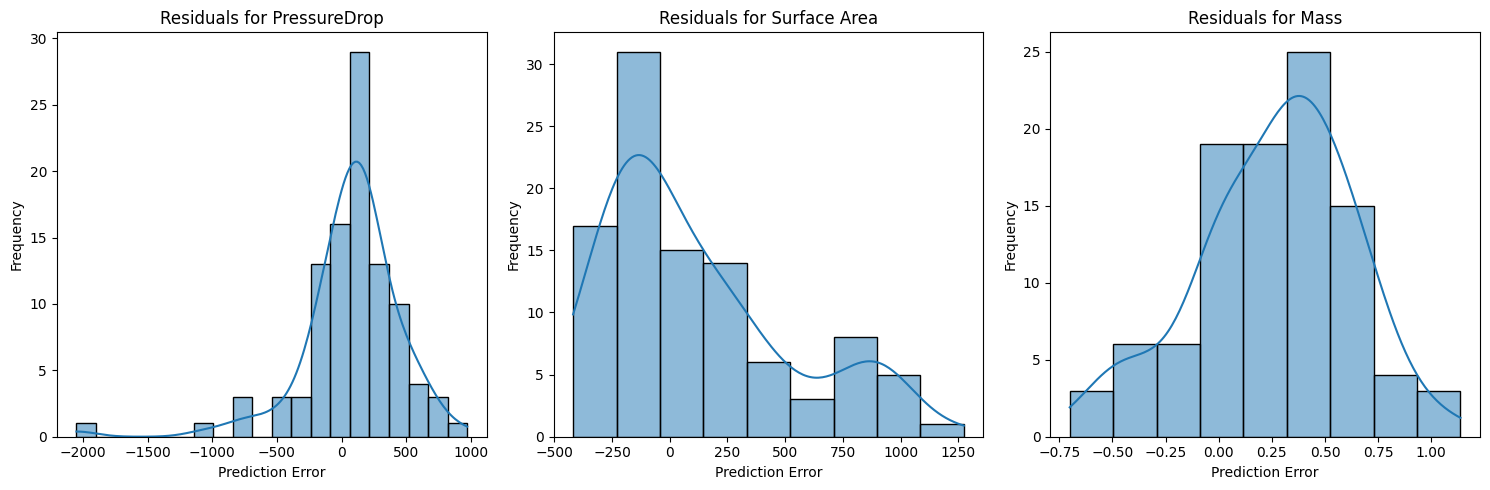

In [13]:
# Phase 2: Targeted Sampling & Model Refinement
# 1. Analyze Baseline Residuals
y_pred_scaled = hypermodel.predict(X_val)
residuals_scaled = y_val - y_pred_scaled

# Inverse transform to get original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_val_orig = scaler_y.inverse_transform(y_val)
residuals = y_val_orig - y_pred

# Calculate Mean Absolute Error for each target
mae_per_target = np.mean(np.abs(residuals), axis=0)
print("Mean Absolute Error for each target:")
for i, target in enumerate(targets):
    print(f"{target}: {mae_per_target[i]:.4f}")

# Visualize residuals
plt.figure(figsize=(15, 5))
for i, target in enumerate(targets):
    plt.subplot(1, len(targets), i + 1)
    sns.histplot(residuals[:, i], kde=True)
    plt.title(f'Residuals for {target}')
    plt.xlabel('Prediction Error')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Top 100 validation points with highest prediction error:
   X Cell Size  YZ Cell Size  Velocity Inlet
0    13.333333     21.666667     3277.777778
1    10.000000     21.666667     3166.666667
2    21.666667     23.333333     3277.777778
3    20.000000     21.666667     3500.000000
4    18.333333     21.666667     2500.000000
5    15.000000     21.666667     2500.000000
6    23.333333     25.000000     3500.000000
7    10.000000     15.000000     3500.000000
8    10.000000     21.666667     2500.000000
9    10.000000     25.000000     3166.666667


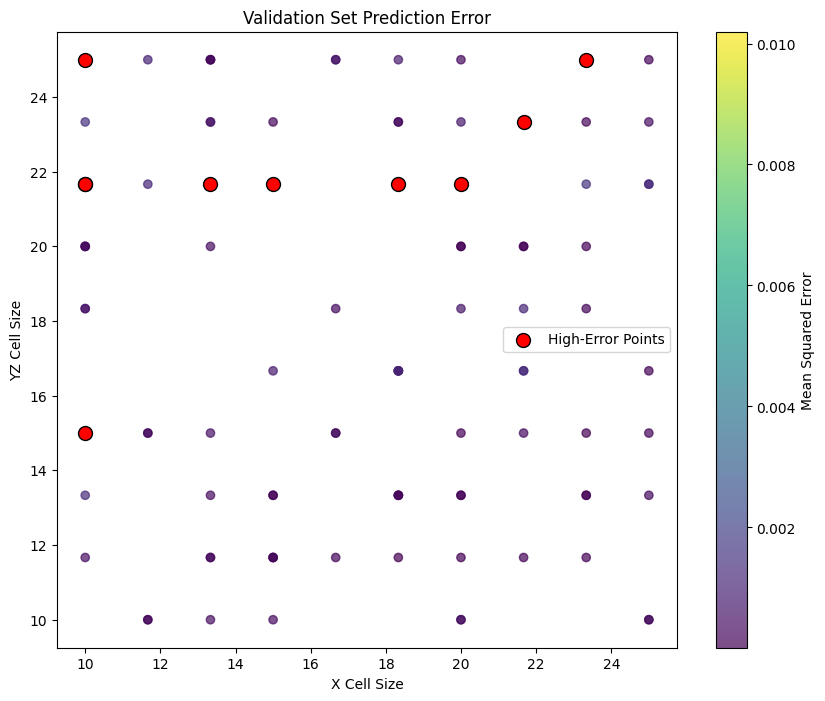

In [14]:
# Identify high-error regions
# We'll use the mean squared error of the scaled residuals to identify the points with the highest error.
mse_per_point = np.mean(np.square(residuals_scaled), axis=1)
# Get top 100 high-error points, or all if less than 100 are available
num_points = min(100, len(X_val))
high_error_indices = np.argsort(mse_per_point)[-10:] 

print(f"Top {num_points} validation points with highest prediction error:")
X_val_orig = scaler_X.inverse_transform(X_val)
high_error_inputs = X_val_orig[high_error_indices]
print(pd.DataFrame(high_error_inputs, columns=features))

# Visualize high-error regions
plt.figure(figsize=(10, 8))
sc = plt.scatter(X_val_orig[:, 0], X_val_orig[:, 1], c=mse_per_point, cmap='viridis', alpha=0.7)
plt.colorbar(sc, label='Mean Squared Error')
plt.scatter(high_error_inputs[:, 0], high_error_inputs[:, 1], color='red', s=100, edgecolor='black', label='High-Error Points')
plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title('Validation Set Prediction Error')
plt.legend()
plt.show()

In [15]:
# 2. Strategic Data Point Generation
import subprocess
import json
import os
import csv

# Define paths and file names
exePath = r"C:/Program Files/nTopology/nTopology/nTopCL.exe"
nTopFilePath = r"nTop/nTop_ASME_Hackathon_HEX.ntop"
Input_File_Name = "input.json"
Output_File_Name = "output.json"
new_csv_file_path = "nTop/augmented_data.csv"

# Check if nTopCL executable exists
if not os.path.exists(exePath):
    print(f"nTopCL.exe not found at {exePath}")
    print("Skipping data generation.")
else:
    # Input variables in JSON structure
    Inputs_JSON = {
        "description": "",
        "inputs": [
            {"description": "", "name": "Cell Size X", "type": "real", "units": "mm", "value": 25.0},
            {"description": "", "name": "Cell Size Y/Z", "type": "real", "units": "mm", "value": 25.0},
            {"description": "", "name": "Inlet Velocity", "type": "real", "units": "mm*s^-1", "value": 3000.0}
        ],
        "title": "Simple Heat Exchanger"
    }

    # nTopCL arguments
    Arguments = [exePath, "-j", Input_File_Name, "-o", Output_File_Name, nTopFilePath]

    print("Generating new data points for high-error regions...")
    # Use the high_error_inputs identified previously
    for i, params in enumerate(high_error_inputs):
        # Set the input parameters in the JSON
        Inputs_JSON['inputs'][0]['value'] = float(params[0]) # X Cell Size
        Inputs_JSON['inputs'][1]['value'] = float(params[1]) # YZ Cell Size
        Inputs_JSON['inputs'][2]['value'] = float(params[2]) # Inlet Velocity
        
        # Create input.json file
        with open(Input_File_Name, 'w') as outfile:
            json.dump(Inputs_JSON, outfile, indent=4)

        # nTopCL call
        print(f"Running simulation for point {i+1}/{len(high_error_inputs)}: {params}")
        process = subprocess.Popen(Arguments, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
        stdout, stderr = process.communicate()

        if process.returncode != 0:
            print(f"Error running nTopCL for point {params}:")
            print(stderr)
            continue

        # Read the JSON from the output file
        with open(Output_File_Name, 'r') as output_file:
            output_data = json.load(output_file)
            # The actual data is nested
            sim_results = output_data[0]['value']['jsonObject']

        # On the first iteration, write headers to the new CSV
        if i == 0:
            # Ensure the directory exists
            os.makedirs(os.path.dirname(new_csv_file_path), exist_ok=True)
            with open(new_csv_file_path, 'w', newline='', encoding='utf-8') as csvfile:
                writer = csv.writer(csvfile)
                writer.writerow(sim_results.keys())
        
        # Append the new data
        with open(new_csv_file_path, 'a', newline='', encoding='utf-8') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(sim_results.values())

    print(f"\nNew data generation complete. Data saved to '{new_csv_file_path}'")

Generating new data points for high-error regions...
Running simulation for point 1/10: [  13.33333333   21.66666667 3277.777778  ]
Running simulation for point 2/10: [  10.           21.66666667 3166.666667  ]
Running simulation for point 3/10: [  21.66666667   23.33333333 3277.777778  ]
Running simulation for point 4/10: [  20.           21.66666667 3500.        ]
Running simulation for point 5/10: [  18.33333333   21.66666667 2500.        ]
Running simulation for point 6/10: [  15.           21.66666667 2500.        ]
Running simulation for point 7/10: [  23.33333333   25.         3500.        ]
Running simulation for point 8/10: [  10.   15. 3500.]
Running simulation for point 9/10: [  10.           21.66666667 2500.        ]
Running simulation for point 10/10: [  10.         25.       3166.666667]

New data generation complete. Data saved to 'nTop/augmented_data.csv'


In [16]:
# 3. Final Model Training
# Load the new data and merge with the original dataset
try:
    new_data = pd.read_csv(new_csv_file_path)
    print(f"Successfully loaded {len(new_data)} new data points.")
    
    # The new data from the simulation contains both inputs and outputs.
    # We need to reorder columns to match the original `data` DataFrame before concatenation.
    
    # Let's construct the new data correctly. The simulation output in `new_data`
    # needs to be combined with the inputs that generated it.
    new_inputs_df = pd.DataFrame(high_error_inputs, columns=features)
    
    # The `new_data` from the CSV has different column names than the original data.
    # Let's select the target columns from the new_data and create the augmented dataframe.
    new_outputs_df = new_data[targets]
    
    # Let's create a new dataframe for the augmented data with the correct columns
    # Reset index to ensure proper alignment
    augmented_df = pd.concat([new_inputs_df.reset_index(drop=True), new_outputs_df.reset_index(drop=True)], axis=1)
    
    # Combine with original data
    combined_data = pd.concat([data, augmented_df], ignore_index=True)
    print("Original and new data combined.")
    print(f"Total dataset size: {len(combined_data)} points.")

    # -- Re-preprocess the entire dataset --
    X_combined = combined_data[features]
    y_combined = combined_data[targets]

    # Standardize inputs & outputs
    scaler_X_final = StandardScaler()
    X_scaled_final = scaler_X_final.fit_transform(X_combined)

    scaler_y_final = StandardScaler()
    y_scaled_final = scaler_y_final.fit_transform(y_combined)

    # Split data
    X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
        X_scaled_final, y_scaled_final, test_size=0.1, random_state=42
    )
    
    print("Combined data has been preprocessed for final training.")

except FileNotFoundError:
    print(f"'{new_csv_file_path}' not found. Skipping final model training.")
    combined_data = None
except Exception as e:
    print(f"An error occurred: {e}")
    combined_data = None

Successfully loaded 10 new data points.
Original and new data combined.
Total dataset size: 1010 points.
Combined data has been preprocessed for final training.


In [17]:
# Retrain the MLP on the combined dataset
if combined_data is not None:
    print("\nRetraining model on the augmented dataset...")
    
    # Set up the tuner for the final training
    tuner_final = kt.Hyperband(build_model,
                               objective='val_loss',
                               max_epochs=50,
                               factor=3,
                               directory='keras_tuner_dir',
                               project_name='asme_hackathon_final',
                               overwrite=True) # Overwrite previous results in this directory

    # Start the new hyperparameter search
    tuner_final.search(X_train_final, y_train_final, 
                       epochs=100, 
                       validation_data=(X_val_final, y_val_final), 
                       callbacks=[stop_early])

    # Get the optimal hyperparameters from the new search
    best_hps_final = tuner_final.get_best_hyperparameters(num_trials=1)[0]

    print(f"""
    The final hyperparameter search is complete. 
    The optimal number of layers is {best_hps_final.get('num_layers')} 
    and the optimal learning rate for the optimizer is {best_hps_final.get('learning_rate')}.
    """)

    # Build the model with the new optimal hyperparameters
    final_model = tuner_final.hypermodel.build(best_hps_final)
    
    # Find the best epoch from the tuning history
    best_epoch_final = tuner_final.oracle.get_best_trials(num_trials=1)[0].best_step

    # Retrain the final model on the full augmented training data for the optimal number of epochs
    history_final = final_model.fit(X_train_final, y_train_final, 
                                    epochs=best_epoch_final,
                                    validation_data=(X_val_final, y_val_final),
                                    callbacks=[stop_early],
                                    verbose=1)
    
    print("\nFinal model training complete.")
    
    # Evaluate the final model
    final_eval_result = final_model.evaluate(X_val_final, y_val_final)
    print(f"\nFinal model evaluation on augmented validation set:")
    print(f"[test loss, test accuracy]: {final_eval_result}")

Trial 90 Complete [00h 00m 03s]
val_loss: 0.038149282336235046

Best val_loss So Far: 0.017968596890568733
Total elapsed time: 00h 03m 25s

    The final hyperparameter search is complete. 
    The optimal number of layers is 3 
    and the optimal learning rate for the optimizer is 0.001.
    
Epoch 1/9
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1656 - mean_absolute_error: 0.2929 - val_loss: 0.0492 - val_mean_absolute_error: 0.1665
Epoch 2/9
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0529 - mean_absolute_error: 0.1733 - val_loss: 0.0432 - val_mean_absolute_error: 0.1493
Epoch 3/9
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0439 - mean_absolute_error: 0.1499 - val_loss: 0.0390 - val_mean_absolute_error: 0.1250
Epoch 4/9
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0385 - mean_absolute_error: 0.1434 - val_loss: 0.0335 - val_mean_absolute_error: 0.1289
Epoch 5/9
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0353 - mean_absolute_error: 0.1390 - val_loss: 0.0351 - v


Analyzing residuals of the final model...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


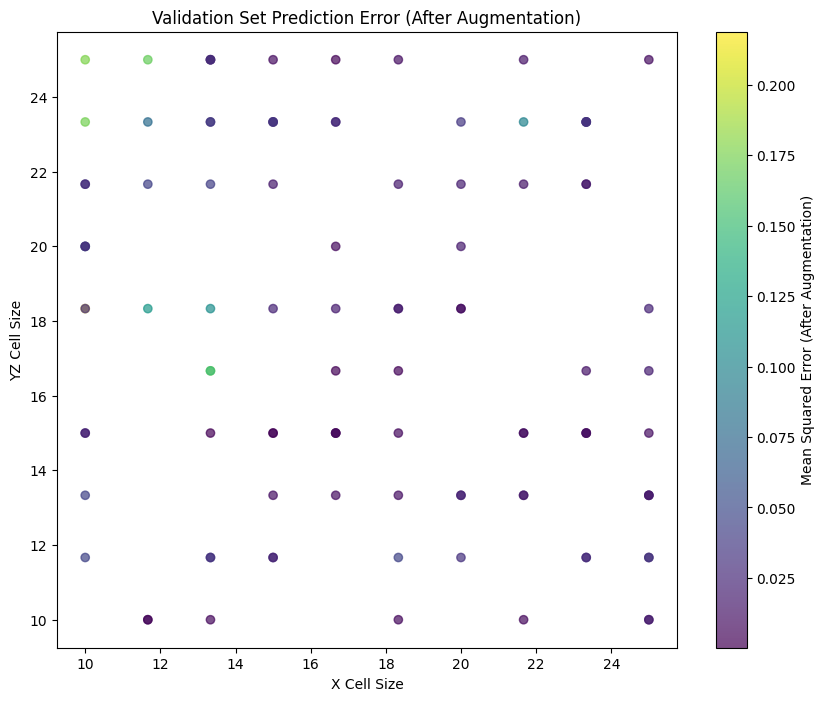


Mean Absolute Error Comparison:
Target         | Before      | After
---------------------------------------
PressureDrop    | 273.1019    | 420.8004
Surface Area    | 309.1575    | 432.5687
Mass            | 0.3772      | 0.7984


In [18]:
# Compare Before vs. After Residual Maps
if combined_data is not None:
    print("\nAnalyzing residuals of the final model...")
    
    # Predict on the validation set with the new model
    y_pred_scaled_final = final_model.predict(X_val_final)
    
    # Calculate new residuals
    residuals_scaled_final = y_val_final - y_pred_scaled_final
    mse_per_point_final = np.mean(np.square(residuals_scaled_final), axis=1)
    
    # Inverse transform for visualization
    X_val_orig_final = scaler_X_final.inverse_transform(X_val_final)

    # Plot the new error map
    plt.figure(figsize=(10, 8))
    sc = plt.scatter(X_val_orig_final[:, 0], X_val_orig_final[:, 1], c=mse_per_point_final, cmap='viridis', alpha=0.7)
    plt.colorbar(sc, label='Mean Squared Error (After Augmentation)')
    plt.xlabel(features[0])
    plt.ylabel(features[1])
    plt.title('Validation Set Prediction Error (After Augmentation)')
    plt.show()

    # You can also compare the MAE before and after
    y_pred_final = scaler_y_final.inverse_transform(y_pred_scaled_final)
    y_val_orig_final = scaler_y_final.inverse_transform(y_val_final)
    residuals_final = y_val_orig_final - y_pred_final
    mae_per_target_final = np.mean(np.abs(residuals_final), axis=0)

    print("\nMean Absolute Error Comparison:")
    print("Target         | Before      | After")
    print("---------------------------------------")
    for i, target in enumerate(targets):
        print(f"{target:<15} | {mae_per_target[i]:<11.4f} | {mae_per_target_final[i]:.4f}")